In [16]:
import numpy as np
import matplotlib.pyplot as plt

In [17]:
duration = 10  # seconds
sampling_rate = 1000  # Hz for continuous sampling
pulsar_period = 1  # seconds (frequency = 1 Hz)
binary_orbit_period = 5  # seconds (modulation frequency = 0.2 Hz)
noise_level = 0.5  # Standard deviation of Gaussian noise
scale_factor = 100  # Scale for Poisson noise

In [18]:
# Continuous sampling time array
t_continuous = np.linspace(0, duration, int(duration * sampling_rate), endpoint=False)

# Discontinuous sampling time array (random intervals)
t_discontinuous = np.sort(np.random.uniform(0, duration, int(duration * sampling_rate / 2)))

In [19]:
# Pulsar signal
pulsar_signal = np.sin(2 * np.pi * t_continuous / pulsar_period) + np.random.normal(0, noise_level, len(t_continuous))

# Binary pulsar signal (Doppler shift effect)
binary_pulsar_signal = np.sin(2 * np.pi * t_continuous / pulsar_period +
                              0.5 * np.sin(2 * np.pi * t_continuous / binary_orbit_period)) + np.random.normal(0, noise_level, len(t_continuous))


In [23]:
# Add Gaussian noise directly
pulsar_signal_discontinuous = np.sin(2 * np.pi * t_discontinuous / pulsar_period) + np.clip(np.random.normal(0, noise_level, len(t_discontinuous)),-0.5,0.5)
binary_pulsar_signal_discontinuous = np.sin(2 * np.pi * t_discontinuous / pulsar_period +
                              0.5 * np.sin(2 * np.pi * t_discontinuous / binary_orbit_period)) + np.clip(np.random.normal(0, noise_level, len(t_discontinuous)),-0.5,0.5)

# Shift signal to ensure positivity for photon counts
pulsar_signal_discontinuous_positive = scale_factor * (pulsar_signal_discontinuous + 1.5)  # Offset by +1.5 for safety
binary_pulsar_signal_discontinuous_positive = scale_factor * (binary_pulsar_signal_discontinuous + 1.5)

# Add Poisson noise
pulsar_signal_discontinuous_poisson_noisy = np.random.poisson(pulsar_signal_discontinuous_positive) / scale_factor
binary_pulsar_signal_discontinuous_poisson_noisy = np.random.poisson(binary_pulsar_signal_discontinuous_positive) / scale_factor


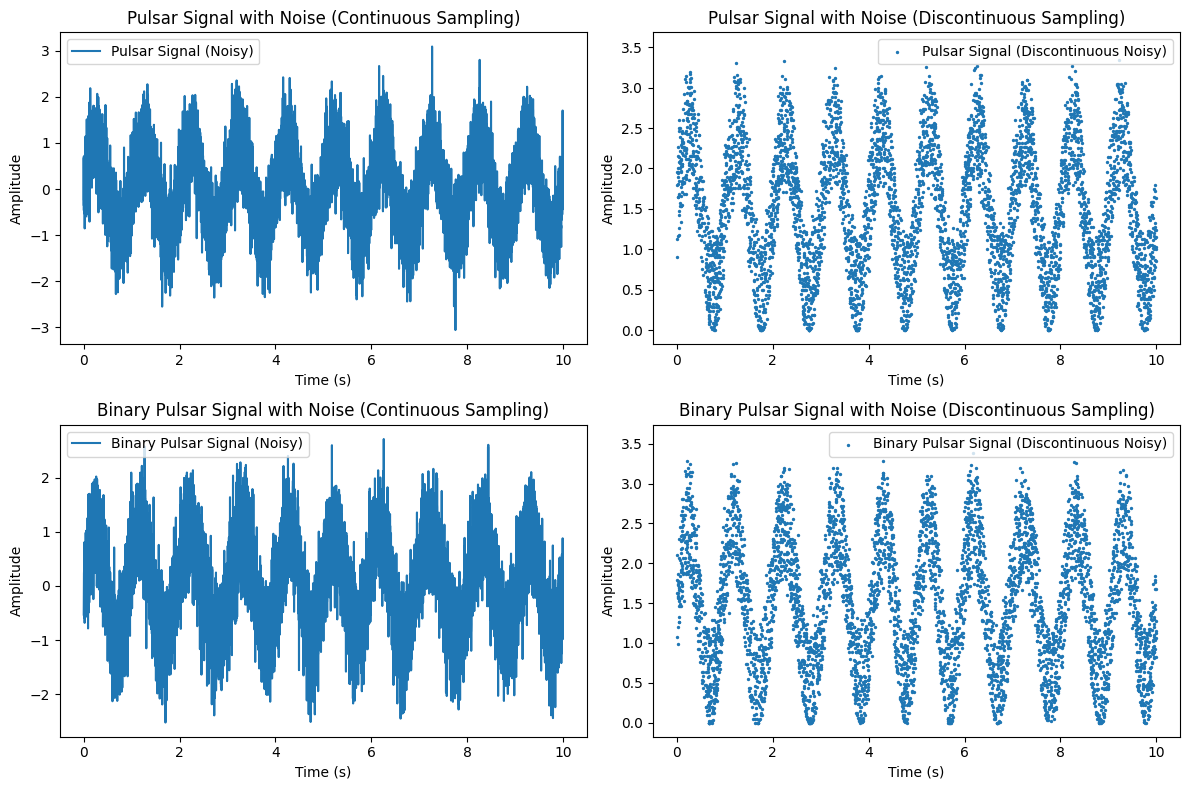

In [26]:
# Plotting
plt.figure(figsize=(12, 8))

# Continuous Pulsar Signal with Noise
plt.subplot(2, 2, 1)
plt.plot(t_continuous, pulsar_signal, label="Pulsar Signal (Noisy)")
plt.title("Pulsar Signal with Noise (Continuous Sampling)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()

# Discontinuous Pulsar Signal with Noise
plt.subplot(2, 2, 2)
plt.scatter(t_discontinuous, pulsar_signal_discontinuous_poisson_noisy, s=2, label="Pulsar Signal (Discontinuous Noisy)")
plt.title("Pulsar Signal with Noise (Discontinuous Sampling)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()

# Continuous Binary Pulsar Signal with Noise
plt.subplot(2, 2, 3)
plt.plot(t_continuous, binary_pulsar_signal, label="Binary Pulsar Signal (Noisy)")
plt.title("Binary Pulsar Signal with Noise (Continuous Sampling)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()

# Discontinuous Binary Pulsar Signal with Noise
plt.subplot(2, 2, 4)
plt.scatter(t_discontinuous, binary_pulsar_signal_discontinuous_poisson_noisy, s=2, label="Binary Pulsar Signal (Discontinuous Noisy)")
plt.title("Binary Pulsar Signal with Noise (Discontinuous Sampling)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()

plt.tight_layout()
plt.show()